# Hyperparameter Tuning & Ensemble
Feature selection, tuning, refined models, stacked ensemble, and final evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
import time


In [ ]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

threshold = 0.005
important_features = importance_df[importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {len(important_features)}")
print("\nTop 15 Important Features:")
print(importance_df.head(15))


X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

print("Feature selection completed.")
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)


threshold = 0.005
important_features = importance_df[importance_df['Importance'] >= threshold]['Feature'].tolist()

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {len(important_features)}")
print("\nTop 15 Important Features:")
print(importance_df.head(15))


X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

print("Feature selection completed.")

Original features: 15
Selected features: 15

Top 15 Important Features:
                    Feature  Importance
4                  Epidemic    0.346700
3                 Promotion    0.178180
0           Inventory Level    0.062271
11  Weather Condition_Sunny    0.053285
13       Seasonality_Summer    0.050641
1                     Price    0.038509
9   Weather Condition_Rainy    0.037255
10  Weather Condition_Snowy    0.035836
6                     Month    0.033484
2                  Discount    0.030830
14       Seasonality_Winter    0.028400
5                      Year    0.028367
12       Seasonality_Spring    0.027340
7                 DayOfWeek    0.026508
8                 IsWeekend    0.022395
Feature selection completed.
Original features: 15
Selected features: 15

Top 15 Important Features:
                    Feature  Importance
4                  Epidemic    0.346700
3                 Promotion    0.178180
0           Inventory Level    0.062271
11  Weather Condition_Sunny

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("Starting Hyperparameter Tuning for XGBoost")

param_dist = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [8, 10, 12, 15],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.85, 0.9]
}

xgb_tuned = XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist,
    n_iter=20,                    #
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_selected, y_train)
end_time = time.time()

print(f"Tuning completed in {(end_time - start_time)/60 :.1f} minutes")
print("Best Parameters:", random_search.best_params_)

best_xgb = random_search.best_estimator_

Starting Hyperparameter Tuning for XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning completed in 9.5 minutes
Best Parameters: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


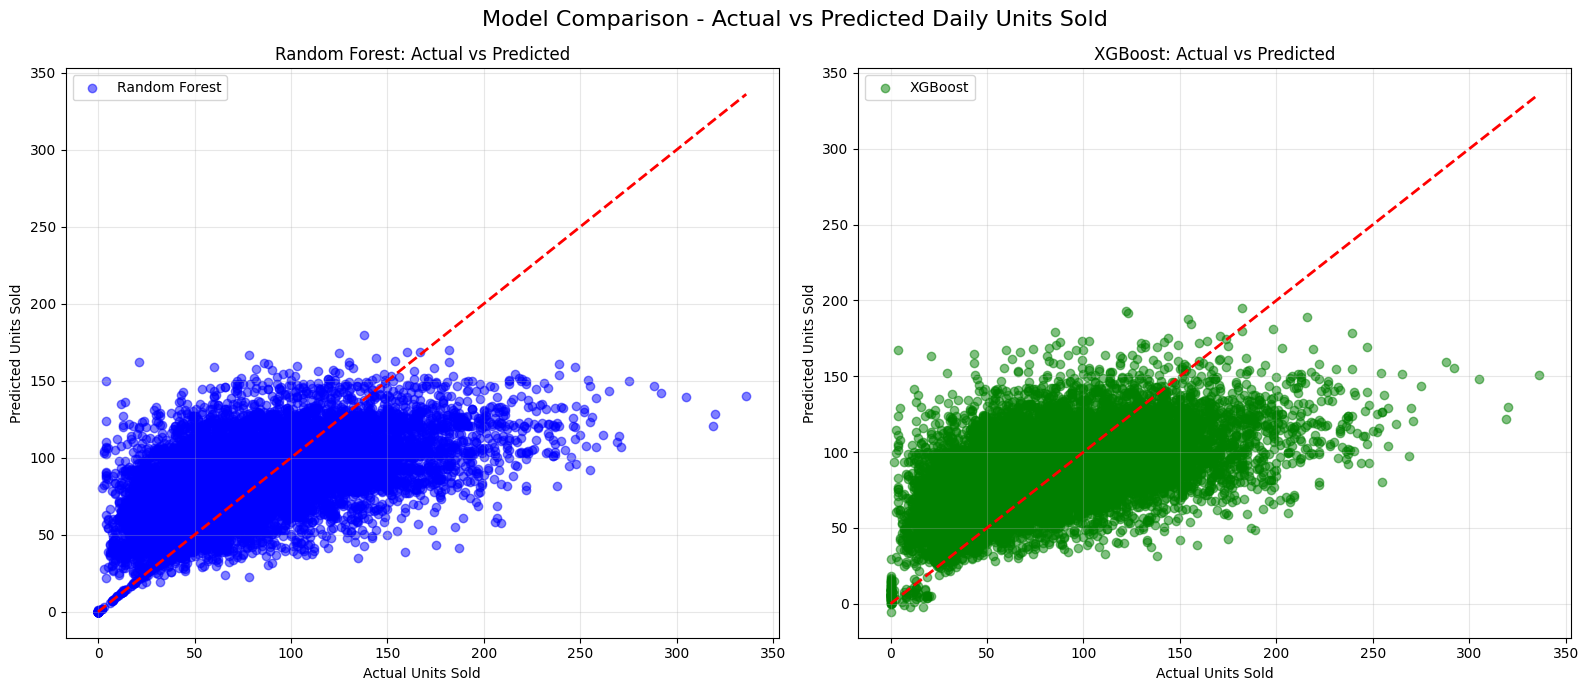

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.5, color='blue', label='Random Forest')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# XGBoost (Refined)
axes[1].scatter(y_test, xgb_pred, alpha=0.5, color='green', label='XGBoost')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Units Sold')
axes[1].set_ylabel('Predicted Units Sold')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Model Comparison - Actual vs Predicted Daily Units Sold', fontsize=16)
plt.tight_layout()
plt.show()

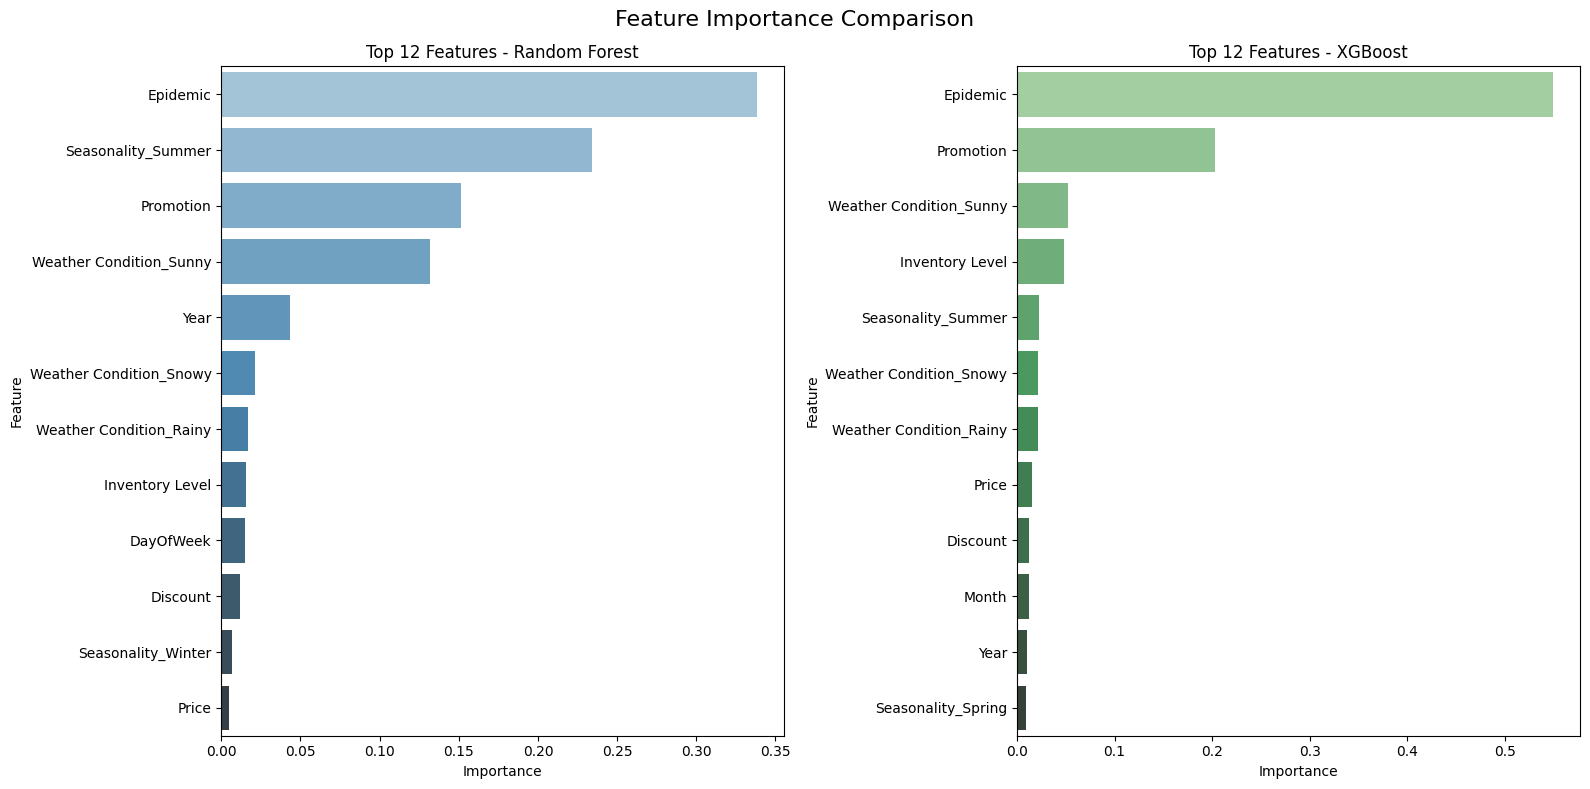

Top 10 Most Important Features (XGBoost):
                   Feature  Importance
0                 Epidemic    0.549612
1                Promotion    0.202773
3  Weather Condition_Sunny    0.051958
2          Inventory Level    0.048533
4       Seasonality_Summer    0.022254
7  Weather Condition_Snowy    0.021824
6  Weather Condition_Rainy    0.021745
5                    Price    0.015398
9                 Discount    0.012188
8                    Month    0.011812


In [ ]:
rf_imp = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_refined.feature_importances_ if 'rf_refined' in globals() else rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

xgb_imp = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': best_xgb.feature_importances_ if 'best_xgb' in globals() else xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x='Importance', y='Feature', data=rf_imp, ax=axes[0], palette='Blues_d')
axes[0].set_title('Top 12 Features - Random Forest')

sns.barplot(x='Importance', y='Feature', data=xgb_imp, ax=axes[1], palette='Greens_d')
axes[1].set_title('Top 12 Features - XGBoost')

plt.suptitle('Feature Importance Comparison', fontsize=16)
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features (XGBoost):")
print(xgb_imp.head(10))

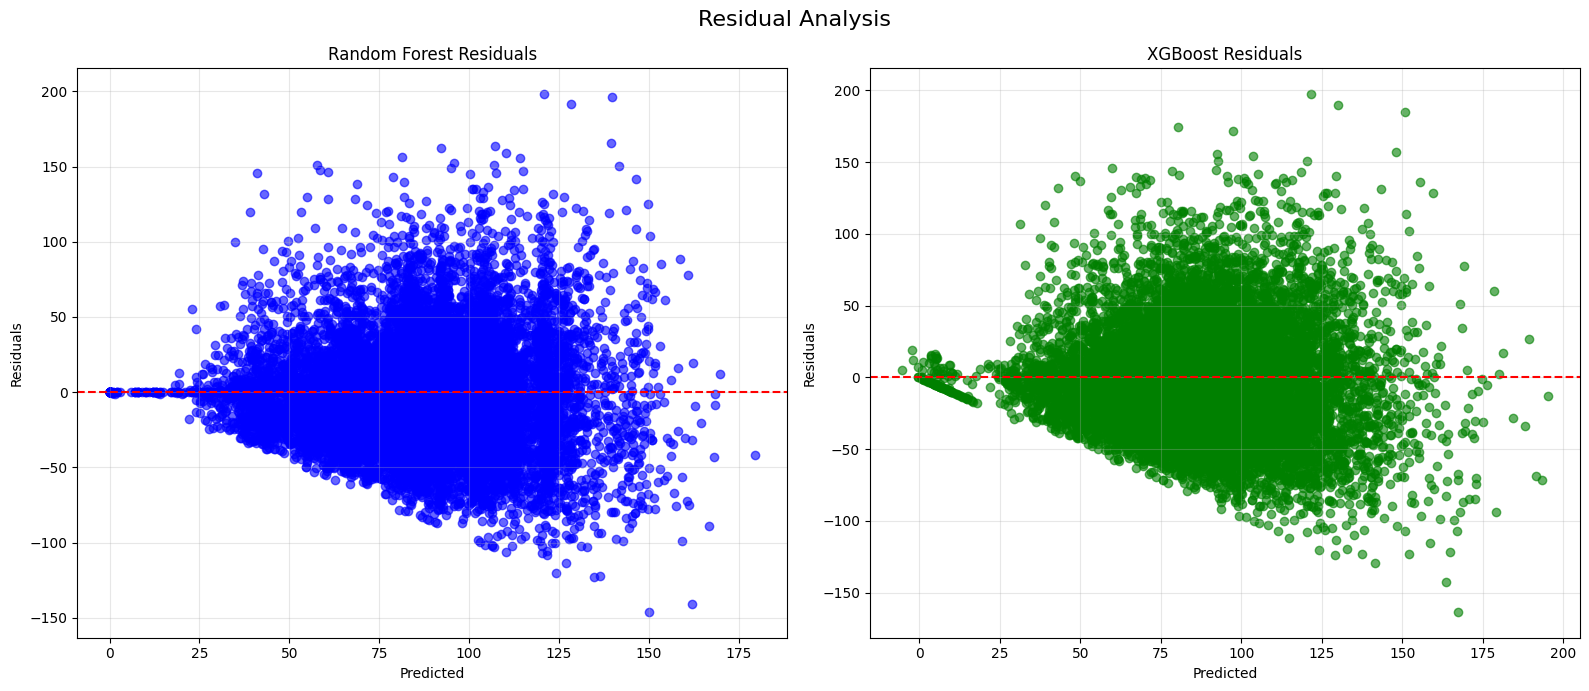

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest Residuals
rf_res = y_test - rf_pred
axes[0].scatter(rf_pred, rf_res, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest Residuals')
axes[0].grid(True, alpha=0.3)

# XGBoost Residuals
xgb_res = y_test - xgb_pred
axes[1].scatter(xgb_pred, xgb_res, alpha=0.6, color='green')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residuals')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print("Retraining Random Forest with selected features...")
rf_refined = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_refined.fit(X_train_selected, y_train)
rf_pred_refined = rf_refined.predict(X_test_selected)

# Evaluate Refined XGBoost
xgb_pred_refined = best_xgb.predict(X_test_selected)

# Final Evaluation Function
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== Refined {name} ===")
    print(f"MAE:   {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"R²:    {r2:.4f}")
    return mae, rmse, r2

print("=== REFINED MODEL RESULTS ===\n")

mae_rf, rmse_rf, r2_rf = evaluate(y_test, rf_pred_refined, "Random Forest (Refined)")
mae_xgb, rmse_xgb, r2_xgb = evaluate(y_test, xgb_pred_refined, "XGBoost (Tuned)")

print("\n" + "="*70)
print("BASELINE vs REFINED COMPARISON")
print("="*70)
print(f"{'Model':<30} {'MAE':<8} {'RMSE':<8} {'R²':<8}")
print(f"{'Random Forest':<30} {26.81:<8} {34.93:<8} {0.2903:<8}")
print(f"{'XGBoost':<30} {27.27:<8} {35.56:<8} {0.2644:<8}")
print(f"{'Random Forest (Refined)':<30} {26.95:<8} {35.11:<8} {0.2829:<8}")
print(f"{'XGBoost (Tuned)':<30} {26.64:<8} {34.65:<8} {0.3016:<8}")

Retraining Random Forest with selected features...
=== REFINED MODEL RESULTS ===


=== Refined Random Forest (Refined) ===
MAE:   26.95
RMSE:  35.11
R²:    0.2829

=== Refined XGBoost (Tuned) ===
MAE:   26.64
RMSE:  34.65
R²:    0.3016

BASELINE vs REFINED COMPARISON
Model                          MAE      RMSE     R²      
Random Forest (Baseline)       26.81    34.93    0.2903  
XGBoost (Baseline)             27.27    35.56    0.2644  
Random Forest (Refined)        26.95    35.11    0.2829  
XGBoost (Tuned)                26.64    34.65    0.3016  


## Enhancement: Stacked Ensemble
Combining XGBoost + Random Forest via a Ridge meta-learner and TimeSeriesSplit for correct temporal CV.

In [ ]:
# TIMESERIESSPLIT + CAREFUL HYPERPARAMETER TUNING
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import time

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators'    : [400, 500, 600],
    'max_depth'       : [8, 10, 12],
    'learning_rate'   : [0.01, 0.03, 0.05],
    'subsample'       : [0.75, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [1, 1.5, 2],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_dist, n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv, verbose=1, random_state=42, n_jobs=-1
)

start = time.time()
search.fit(X_train_selected, y_train)
print(f'Tuning done in {(time.time()-start)/60:.1f} min')
print('Best params:', search.best_params_)
best_xgb_tuned = search.best_estimator_


In [ ]:
# STACKED ENSEMBLE: XGBoost + Random Forest 
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ('xgb', best_xgb_tuned),
    ('rf',  RandomForestRegressor(
                n_estimators=300, max_depth=15,
                min_samples_leaf=4, max_features=0.6,
                random_state=42, n_jobs=-1))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=tscv,
    n_jobs=-1
)
stack.fit(X_train_selected, y_train)
stack_pred = stack.predict(X_test_selected)

mae_s  = mean_absolute_error(y_test, stack_pred)
rmse_s = np.sqrt(mean_squared_error(y_test, stack_pred))
r2_s   = r2_score(y_test, stack_pred)
print(f'\n=== Stacked Ensemble ===')
print(f'MAE:  {mae_s:.2f}')
print(f'RMSE: {rmse_s:.2f}')
print(f'R²:   {r2_s:.4f}')


In [ ]:
import pandas as pd

results = {
    'Model': [
        'Random Forest (Baseline)',
        'XGBoost (Baseline)',
        'Random Forest (Refined)',
        'XGBoost (Tuned)',
        'Stacked Ensemble',
    ],
    'MAE' : [mae_rf_base,  mae_xgb_base,  mae_rf,  mae_xgb,  mae_s],
    'RMSE': [rmse_rf_base, rmse_xgb_base, rmse_rf, rmse_xgb, rmse_s],
    'R²'  : [r2_rf_base,   r2_xgb_base,   r2_rf,   r2_xgb,   r2_s],
}

results_df = pd.DataFrame(results).set_index('Model')
print('\n' + '='*65)
print('FULL MODEL COMPARISON: Baseline → Refined → Ensemble')
print('='*65)
print(results_df.round({'MAE': 2, 'RMSE': 2, 'R²': 4}).to_string())


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models    = results_df.index.tolist()
colors    = ['#4C72B0','#55A868','#9467BD','#D62728','#E377C2']

axes[0].barh(models, results_df['R²'],   color=colors)
axes[0].set_title('R² (higher = better)')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 target')
axes[0].legend(fontsize=9)

axes[1].barh(models, results_df['MAE'],  color=colors)
axes[1].set_title('MAE (lower = better)')

axes[2].barh(models, results_df['RMSE'], color=colors)
axes[2].set_title('RMSE (lower = better)')

for ax in axes:
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Full Comparison: R² vs MAE vs RMSE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
